# 03 - Evaluacion de modelos (validacion cruzada + visualizaciones)

## Contexto

Este notebook implementa la **Fase 5** del proyecto. En el notebook 02 entrenamos 8 pipelines (4 regresion + 4 clasificacion) con un solo split 80/20 y reportamos metricas en train/test. Aqui hacemos la evaluacion **rigurosa** que exige la rubrica IEE 2.2.1 (30% del encargo grupal):

- **Validacion cruzada robusta:** `cross_validate` con `cv=5` y `shuffle=True`. `StratifiedKFold` para clasificacion (preserva el balance 50/50 en cada fold), `KFold` para regresion.
- **Multiples metricas:** R^2, MAE, RMSE y MAPE en regresion; Accuracy, Precision, Recall, F1 y ROC-AUC en clasificacion. `return_train_score=True` en ambos para detectar overfitting con el gap train-test.
- **Visualizaciones avanzadas:** matrices de confusion, curvas ROC, graficos de residuos, prediccion vs real, histograma de errores.
- **Comparacion CV vs test:** contrastar la media de CV con el valor de test del notebook 02 para juzgar estabilidad.
- **Recomendacion concreta** para Fase 6 (tuning): los 2 mejores modelos por tarea.

El notebook usa los pipelines serializados en `models/*.joblib` para las visualizaciones diagnosticas (necesitan un modelo entrenado en train completo), y crea pipelines nuevos del mismo tipo para correr la CV (porque CV reentrena en cada fold de todas formas).

La logica reutilizable vive en `src/model_evaluation.py`; este notebook orquesta, narra y visualiza.


## Setup del entorno (Colab o local)

Mismo patron que el notebook 02. Detecta el entorno y, en Colab, clona el repo `devsal-ml` desde `main` antes de continuar.


In [1]:
import os
import sys
import subprocess
from pathlib import Path

REPO_URL = 'https://github.com/Nicossm/devsal-ml.git'
REPO_BRANCH = 'main'
REPO_NAME = 'devsal-ml'

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    base = Path('/content')
    repo_dir = base / REPO_NAME
    if not repo_dir.exists():
        print(f'Clonando {REPO_URL} (rama {REPO_BRANCH}) en {repo_dir}...')
        subprocess.run(
            ['git', 'clone', '--branch', REPO_BRANCH, '--depth', '1', REPO_URL, str(repo_dir)],
            check=True,
        )
    else:
        print(f'Repo ya presente en {repo_dir}, omito clone.')
    os.chdir(repo_dir / 'notebooks')
    print(f'cwd: {Path.cwd()}')
else:
    print(f'Entorno local detectado. cwd: {Path.cwd()}')


Entorno local detectado. cwd: /home/nicolas/U/PrograCien/parcial1/notebooks


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from src.model_training import (
    build_classification_pipeline,
    build_preprocessor,
    build_regression_pipeline,
    create_binary_target,
    load_data,
)
from src.model_evaluation import (
    build_comparison_table,
    cross_validate_classification,
    cross_validate_regression,
    plot_confusion_matrices,
    plot_residuals,
    plot_roc_curves,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
DATA_PATH = PROJECT_ROOT / 'etl' / 'data' / 'processed' / 'clean.csv'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Carga de datos y replica del split del notebook 02

Usamos exactamente el mismo split 80/20 con `random_state=42` que el notebook 02. Esto es deliberado: las metricas de test que reporte este notebook tienen que ser **comparables** a las del 02, asi podemos cruzarlas con las medias de CV.

La variable binaria de clasificacion se reconstruye con la mediana de `y_train` (sin leakage), igual que en el 02.


In [3]:
df = load_data(str(DATA_PATH))

NUMERIC_FEATURES = ['experience', 'num_languages', 'num_frameworks']
CATEGORICAL_FEATURES = ['country', 'education', 'company_size']
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'salary_usd'

X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
y_train_bin, y_test_bin, threshold = create_binary_target(y_train, y_test)

print(f'Dataset: {df.shape[0]} filas | features: {len(FEATURES)}')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Umbral binario (mediana y_train): ${threshold:,.2f}')
print(f'CV folds: {CV_FOLDS} | random_state: {RANDOM_STATE}')


Dataset: 9249 filas | features: 6
X_train: (7399, 6) | X_test: (1850, 6)
Umbral binario (mediana y_train): $130,220.00
CV folds: 5 | random_state: 42


## 2. Preprocessor compartido para los pipelines de CV

Para la CV creamos pipelines **nuevos** del mismo tipo (con los mismos hiperparametros default) en vez de reusar los `.joblib`. Motivo: `cross_validate` reentrena el estimador en cada fold de todas formas, asi que reusar el modelo ya entrenado no aportaria; ademas asi documentamos explicitamente en el notebook como se construye cada pipeline.

Las visualizaciones diagnosticas (matrices de confusion, ROC, residuos) si usan los `.joblib` cargados de `models/`, porque ahi necesitamos las predicciones de un modelo entrenado en train completo (no de los modelos parciales de cada fold).


In [4]:
preprocessor = build_preprocessor(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
)


## 3. Carga de los pipelines entrenados en el notebook 02

Cargamos los 8 `.joblib` que produjo el notebook 02 para las visualizaciones diagnosticas. Si esta corrida es la primera (Colab fresh), los archivos pueden no existir todavia -- en ese caso es necesario ejecutar primero el notebook 02. Como salvaguarda, mostramos un mensaje claro.


In [5]:
REG_JOBLIB = {
    'LinearRegression': MODELS_DIR / 'reg_linear.joblib',
    'Ridge': MODELS_DIR / 'reg_ridge.joblib',
    'RandomForestRegressor': MODELS_DIR / 'reg_random_forest.joblib',
    'GradientBoostingRegressor': MODELS_DIR / 'reg_gradient_boosting.joblib',
}
CLF_JOBLIB = {
    'LogisticRegression': MODELS_DIR / 'clf_logistic.joblib',
    'SVM': MODELS_DIR / 'clf_svm.joblib',
    'RandomForestClassifier': MODELS_DIR / 'clf_random_forest.joblib',
    'GradientBoostingClassifier': MODELS_DIR / 'clf_gradient_boosting.joblib',
}

missing = [p for p in list(REG_JOBLIB.values()) + list(CLF_JOBLIB.values()) if not p.exists()]
if missing:
    raise FileNotFoundError(
        'Faltan modelos serializados:\n  - ' + '\n  - '.join(str(p) for p in missing) +
        '\n\nEjecuta primero el notebook 02_supervised_modeling.ipynb para regenerarlos.'
    )

reg_models = {name: joblib.load(p) for name, p in REG_JOBLIB.items()}
clf_models = {name: joblib.load(p) for name, p in CLF_JOBLIB.items()}
print(f'Cargados {len(reg_models)} pipelines de regresion y {len(clf_models)} de clasificacion.')


Cargados 4 pipelines de regresion y 4 de clasificacion.


## 4. Validacion cruzada — Regresion

**Por que CV y no solo el split 80/20 del notebook 02:** un solo split puede dar una metrica engañosa si justo el subconjunto de test es especialmente facil o dificil. CV con 5 folds promedia 5 evaluaciones distintas sobre todo el dataset y reporta tambien la **desviacion estandar** entre folds -- una `std` chica significa que el modelo es estable; una `std` grande significa que su rendimiento depende mucho de que datos vea.

**Que esperar:** consistente con el 02, los lineales (Linear, Ridge) y Gradient Boosting deberian quedar arriba en R^2; Random Forest deberia mostrar el gap train-test mas grande (overfit con defaults).

**Limitaciones:** CV con KFold simple asume que todas las filas son intercambiables. En un dataset con estructura temporal o de grupo eso no se cumple; aqui no hay estructura temporal, asi que KFold con shuffle es lo correcto.


In [6]:
reg_cv = {}
reg_cv['LinearRegression'] = cross_validate_regression(
    build_regression_pipeline(LinearRegression(), preprocessor),
    X_train, y_train, cv=CV_FOLDS, random_state=RANDOM_STATE,
)
reg_cv['Ridge'] = cross_validate_regression(
    build_regression_pipeline(Ridge(random_state=RANDOM_STATE), preprocessor),
    X_train, y_train, cv=CV_FOLDS, random_state=RANDOM_STATE,
)
reg_cv['RandomForestRegressor'] = cross_validate_regression(
    build_regression_pipeline(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), preprocessor
    ),
    X_train, y_train, cv=CV_FOLDS, random_state=RANDOM_STATE,
)
reg_cv['GradientBoostingRegressor'] = cross_validate_regression(
    build_regression_pipeline(
        GradientBoostingRegressor(random_state=RANDOM_STATE), preprocessor
    ),
    X_train, y_train, cv=CV_FOLDS, random_state=RANDOM_STATE,
)

for name, res in reg_cv.items():
    print(f'\n{name}')
    print(f'  TEST  R2={res["test"]["R2_mean"]:.4f}+-{res["test"]["R2_std"]:.4f}  '
          f'MAE={res["test"]["MAE_mean"]:,.0f}+-{res["test"]["MAE_std"]:,.0f}  '
          f'RMSE={res["test"]["RMSE_mean"]:,.0f}+-{res["test"]["RMSE_std"]:,.0f}  '
          f'MAPE={res["test"]["MAPE_mean"]:.3f}+-{res["test"]["MAPE_std"]:.3f}')
    print(f'  TRAIN R2={res["train"]["R2_mean"]:.4f}+-{res["train"]["R2_std"]:.4f}  '
          f'fit_time={res["fit_time_mean"]:.2f}s')



LinearRegression
  TEST  R2=0.7613+-0.0230  MAE=16,066+-220  RMSE=23,633+-1,026  MAPE=0.129+-0.004
  TRAIN R2=0.7636+-0.0057  fit_time=0.04s

Ridge
  TEST  R2=0.7613+-0.0230  MAE=16,067+-219  RMSE=23,633+-1,025  MAPE=0.129+-0.004
  TRAIN R2=0.7636+-0.0057  fit_time=0.03s

RandomForestRegressor
  TEST  R2=0.6988+-0.0222  MAE=18,214+-183  RMSE=26,561+-683  MAPE=0.149+-0.003
  TRAIN R2=0.9061+-0.0023  fit_time=7.67s

GradientBoostingRegressor
  TEST  R2=0.7573+-0.0222  MAE=16,320+-215  RMSE=23,837+-978  MAPE=0.133+-0.004
  TRAIN R2=0.7728+-0.0054  fit_time=0.75s


### 4.1 Tabla comparativa de regresion

Ordenada por `R2_mean_test` descendente. Guardada en `results/cv_regression.csv` para usar en el informe.


In [7]:
reg_table = build_comparison_table(reg_cv, sort_by='R2_mean_test', ascending=False)
reg_cols_main = ['R2_mean_test', 'R2_std_test', 'MAE_mean_test', 'RMSE_mean_test',
                 'MAPE_mean_test', 'R2_mean_train', 'gap_R2', 'fit_time_mean']
reg_table_main = reg_table[reg_cols_main].round(4)
reg_table.to_csv(RESULTS_DIR / 'cv_regression.csv')
print(f'Tabla exportada a {RESULTS_DIR / "cv_regression.csv"}')
reg_table_main


Tabla exportada a /home/nicolas/U/PrograCien/parcial1/results/cv_regression.csv


,R2_mean_test,R2_std_test,MAE_mean_test,RMSE_mean_test,MAPE_mean_test,R2_mean_train,gap_R2,fit_time_mean
Modelo,,,,,,,,
Ridge,0.7613,0.0230,16066.7601,23632.9092,0.1289,0.7636,0.0023,0.0345
LinearRegression,0.7613,0.0230,16066.2376,23633.1537,0.1289,0.7636,0.0023,0.0370
GradientBoostingRegressor,0.7573,0.0222,16319.6928,23837.4248,0.1325,0.7728,0.0156,0.7519
RandomForestRegressor,0.6988,0.0222,18213.5872,26560.6715,0.1488,0.9061,0.2073,7.6666


### 4.2 Visualizaciones comparativas de regresion


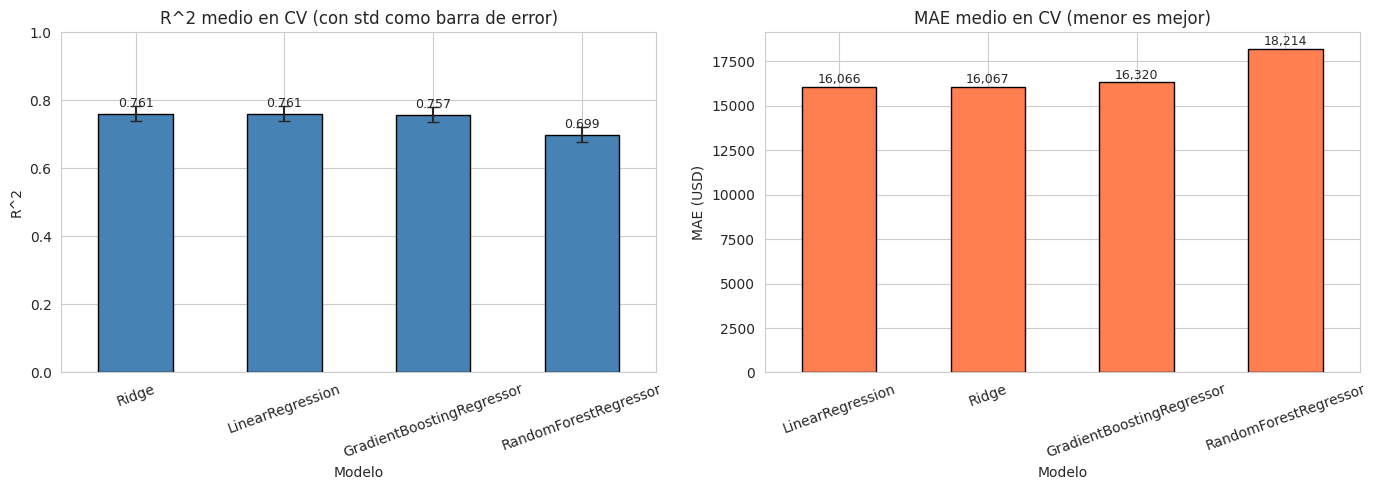

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_table_main['R2_mean_test'].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black',
    yerr=reg_table_main['R2_std_test'], capsize=4,
)
axes[0].set_title('R^2 medio en CV (con std como barra de error)')
axes[0].set_ylabel('R^2')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(reg_table_main['R2_mean_test']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

mae_sorted = reg_table_main.sort_values('MAE_mean_test')
mae_sorted['MAE_mean_test'].plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black',
)
axes[1].set_title('MAE medio en CV (menor es mejor)')
axes[1].set_ylabel('MAE (USD)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(mae_sorted['MAE_mean_test']):
    axes[1].text(i, v + max(mae_sorted['MAE_mean_test']) * 0.01,
                 f'{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 4.3 Analisis de overfitting (gap train-test)

El `gap_R2 = R2_train - R2_test` mide cuanto baja el desempeno al pasar de los datos vistos a los no vistos. Interpretacion:

- **gap < 0.05:** el modelo generaliza bien; lo que aprendio en train se traduce a test.
- **gap entre 0.05 y 0.15:** overfitting moderado; algo de capacidad sobrante.
- **gap > 0.15:** overfitting fuerte; el modelo memorizo train y no generaliza. Senal clara de que hay que tunear hiperparametros restrictivos (`max_depth`, `min_samples_leaf`).


In [9]:
print('Gap R^2 (train_mean - test_mean) por modelo:')
for name, gap in reg_table['gap_R2'].sort_values(ascending=False).items():
    tag = '  <-- overfit fuerte' if gap > 0.15 else ('  <-- overfit moderado' if gap > 0.05 else '')
    print(f'  {name:30s}  gap_R2={gap:+.3f}{tag}')


Gap R^2 (train_mean - test_mean) por modelo:
  RandomForestRegressor           gap_R2=+0.207  <-- overfit fuerte
  GradientBoostingRegressor       gap_R2=+0.016
  LinearRegression                gap_R2=+0.002
  Ridge                           gap_R2=+0.002


## 5. Validacion cruzada — Clasificacion

**Por que StratifiedKFold:** el target binario esta balanceado ~50/50, pero StratifiedKFold **garantiza** que cada fold mantenga ese balance. Sin estratificar, podria haber folds ligeramente desbalanceados que harian inestable la metrica ROC-AUC.

**Que esperar:** Logistic, SVM y Gradient Boosting deberian quedar empatados arriba en F1 (consistente con el 02). Random Forest mostrara el gap mas grande.

**Limitaciones:** las 5 evaluaciones del CV se hacen sobre subconjuntos del train set del 02 (7399 filas). Si el dataset fuera mas pequeño, valdria la pena `cv=10`; con ~7K filas, 5 folds es suficiente para estimaciones estables.


In [10]:
clf_cv = {}
clf_cv['LogisticRegression'] = cross_validate_classification(
    build_classification_pipeline(
        LogisticRegression(random_state=RANDOM_STATE, max_iter=1000), preprocessor
    ),
    X_train, y_train_bin, cv=CV_FOLDS, random_state=RANDOM_STATE,
)
clf_cv['SVM'] = cross_validate_classification(
    build_classification_pipeline(
        SVC(probability=True, random_state=RANDOM_STATE), preprocessor
    ),
    X_train, y_train_bin, cv=CV_FOLDS, random_state=RANDOM_STATE,
)
clf_cv['RandomForestClassifier'] = cross_validate_classification(
    build_classification_pipeline(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), preprocessor
    ),
    X_train, y_train_bin, cv=CV_FOLDS, random_state=RANDOM_STATE,
)
clf_cv['GradientBoostingClassifier'] = cross_validate_classification(
    build_classification_pipeline(
        GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor
    ),
    X_train, y_train_bin, cv=CV_FOLDS, random_state=RANDOM_STATE,
)

for name, res in clf_cv.items():
    print(f'\n{name}')
    print(f'  TEST  F1={res["test"]["F1_mean"]:.4f}+-{res["test"]["F1_std"]:.4f}  '
          f'AUC={res["test"]["ROC_AUC_mean"]:.4f}+-{res["test"]["ROC_AUC_std"]:.4f}  '
          f'Acc={res["test"]["Accuracy_mean"]:.4f}  '
          f'Prec={res["test"]["Precision_mean"]:.4f}  '
          f'Rec={res["test"]["Recall_mean"]:.4f}')
    print(f'  TRAIN F1={res["train"]["F1_mean"]:.4f}  fit_time={res["fit_time_mean"]:.2f}s')



LogisticRegression
  TEST  F1=0.8771+-0.0071  AUC=0.9544+-0.0021  Acc=0.8777  Prec=0.8811  Rec=0.8732
  TRAIN F1=0.8776  fit_time=0.05s

SVM
  TEST  F1=0.8681+-0.0058  AUC=0.9499+-0.0018  Acc=0.8696  Prec=0.8779  Rec=0.8586
  TRAIN F1=0.8877  fit_time=6.62s

RandomForestClassifier
  TEST  F1=0.8561+-0.0086  AUC=0.9367+-0.0064  Acc=0.8562  Prec=0.8564  Rec=0.8559
  TRAIN F1=0.9614  fit_time=1.91s

GradientBoostingClassifier
  TEST  F1=0.8769+-0.0103  AUC=0.9544+-0.0029  Acc=0.8769  Prec=0.8765  Rec=0.8773
  TRAIN F1=0.8828  fit_time=1.01s


### 5.1 Tabla comparativa de clasificacion

Ordenada por `F1_mean_test`. Guardada en `results/cv_classification.csv`.


In [11]:
clf_table = build_comparison_table(clf_cv, sort_by='F1_mean_test', ascending=False)
clf_cols_main = ['F1_mean_test', 'F1_std_test', 'ROC_AUC_mean_test', 'Accuracy_mean_test',
                 'Precision_mean_test', 'Recall_mean_test', 'F1_mean_train', 'gap_F1',
                 'fit_time_mean']
clf_table_main = clf_table[clf_cols_main].round(4)
clf_table.to_csv(RESULTS_DIR / 'cv_classification.csv')
print(f'Tabla exportada a {RESULTS_DIR / "cv_classification.csv"}')
clf_table_main


Tabla exportada a /home/nicolas/U/PrograCien/parcial1/results/cv_classification.csv


,F1_mean_test,F1_std_test,ROC_AUC_mean_test,Accuracy_mean_test,Precision_mean_test,Recall_mean_test,F1_mean_train,gap_F1,fit_time_mean
Modelo,,,,,,,,,
LogisticRegression,0.8771,0.0071,0.9544,0.8777,0.8811,0.8732,0.8776,0.0005,0.0510
GradientBoostingClassifier,0.8769,0.0103,0.9544,0.8769,0.8765,0.8773,0.8828,0.0060,1.0096
SVM,0.8681,0.0058,0.9499,0.8696,0.8779,0.8586,0.8877,0.0196,6.6158
RandomForestClassifier,0.8561,0.0086,0.9367,0.8562,0.8564,0.8559,0.9614,0.1054,1.9091


### 5.2 Visualizaciones comparativas de clasificacion


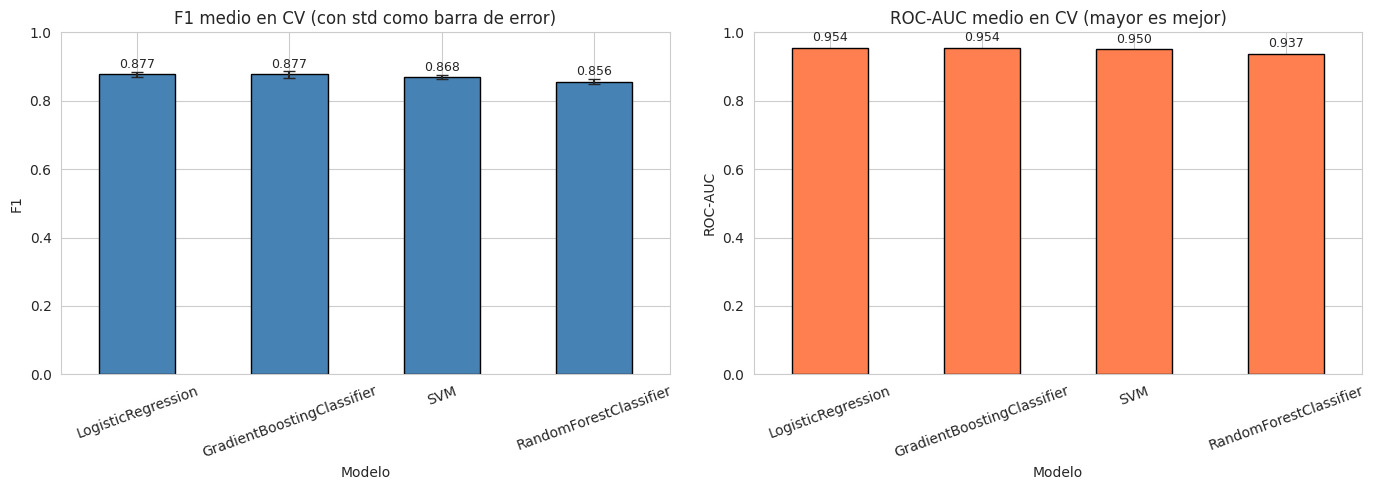

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clf_table_main['F1_mean_test'].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black',
    yerr=clf_table_main['F1_std_test'], capsize=4,
)
axes[0].set_title('F1 medio en CV (con std como barra de error)')
axes[0].set_ylabel('F1')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(clf_table_main['F1_mean_test']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

auc_sorted = clf_table_main.sort_values('ROC_AUC_mean_test', ascending=False)
auc_sorted['ROC_AUC_mean_test'].plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black',
)
axes[1].set_title('ROC-AUC medio en CV (mayor es mejor)')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(auc_sorted['ROC_AUC_mean_test']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 5.3 Analisis de overfitting (gap F1 train-test)


In [13]:
print('Gap F1 (train_mean - test_mean) por modelo:')
for name, gap in clf_table['gap_F1'].sort_values(ascending=False).items():
    tag = '  <-- overfit fuerte' if gap > 0.15 else ('  <-- overfit moderado' if gap > 0.05 else '')
    print(f'  {name:30s}  gap_F1={gap:+.3f}{tag}')


Gap F1 (train_mean - test_mean) por modelo:
  RandomForestClassifier          gap_F1=+0.105  <-- overfit moderado
  SVM                             gap_F1=+0.020
  GradientBoostingClassifier      gap_F1=+0.006
  LogisticRegression              gap_F1=+0.001


## 6. Comparacion CV vs valor de test del notebook 02

**Por que esta comparacion importa:** si la media de CV (5 evaluaciones independientes) esta cerca del valor de test reportado en el 02 (1 evaluacion sobre un split fijo), entonces el modelo es **estable** y el test del 02 no fue una casualidad. Si hay gap grande, el test del 02 fue suerte o mala suerte y deberiamos confiar mas en la CV.

Reusamos los `.joblib` cargados para sacar las predicciones sobre el mismo `X_test` que uso el 02 y comparar contra `R2_mean_test` y `F1_mean_test` de CV.


In [14]:
from sklearn.metrics import r2_score, f1_score

reg_check_rows = []
for name, pipe in reg_models.items():
    r2_test = r2_score(y_test, pipe.predict(X_test))
    r2_cv = reg_cv[name]['test']['R2_mean']
    reg_check_rows.append({
        'Modelo': name,
        'R2_test_nb02': r2_test,
        'R2_cv_mean': r2_cv,
        'diff': r2_test - r2_cv,
    })
reg_check = pd.DataFrame(reg_check_rows).set_index('Modelo').round(4)
print('REGRESION - comparacion R2:')
print(reg_check.to_string())

clf_check_rows = []
for name, pipe in clf_models.items():
    f1_test = f1_score(y_test_bin, pipe.predict(X_test))
    f1_cv = clf_cv[name]['test']['F1_mean']
    clf_check_rows.append({
        'Modelo': name,
        'F1_test_nb02': f1_test,
        'F1_cv_mean': f1_cv,
        'diff': f1_test - f1_cv,
    })
clf_check = pd.DataFrame(clf_check_rows).set_index('Modelo').round(4)
print('\nCLASIFICACION - comparacion F1:')
print(clf_check.to_string())


REGRESION - comparacion R2:
                           R2_test_nb02  R2_cv_mean    diff
Modelo                                                     
LinearRegression                 0.7473      0.7613 -0.0140
Ridge                            0.7473      0.7613 -0.0140
RandomForestRegressor            0.6671      0.6988 -0.0317
GradientBoostingRegressor        0.7402      0.7573 -0.0171



CLASIFICACION - comparacion F1:
                            F1_test_nb02  F1_cv_mean    diff
Modelo                                                      
LogisticRegression                0.8610      0.8771 -0.0161
SVM                               0.8607      0.8681 -0.0074
RandomForestClassifier            0.8461      0.8561 -0.0100
GradientBoostingClassifier        0.8619      0.8769 -0.0150


**Lectura:** diferencias absolutas menores a la `std` de la CV indican modelos estables. Si `|diff|` supera ~1.5x la `std` de CV, el valor de test del 02 cae fuera del intervalo de confianza tipico y conviene reportar la CV como metrica primaria.


## 7. Matrices de confusion (clasificacion)

Cada matriz desglosa los aciertos y errores en las 2 clases. **TP (1,1)** = sobre la mediana correctamente identificado; **TN (0,0)** = bajo la mediana correctamente identificado; **FP (0,1)** = predicho como sobre la mediana cuando no lo era; **FN (1,0)** = predicho como bajo la mediana cuando si lo superaba.

Para un problema balanceado, una matriz simetrica (FP ~ FN) es saludable; un desbalance fuerte significa que el modelo tiene un sesgo hacia una clase.


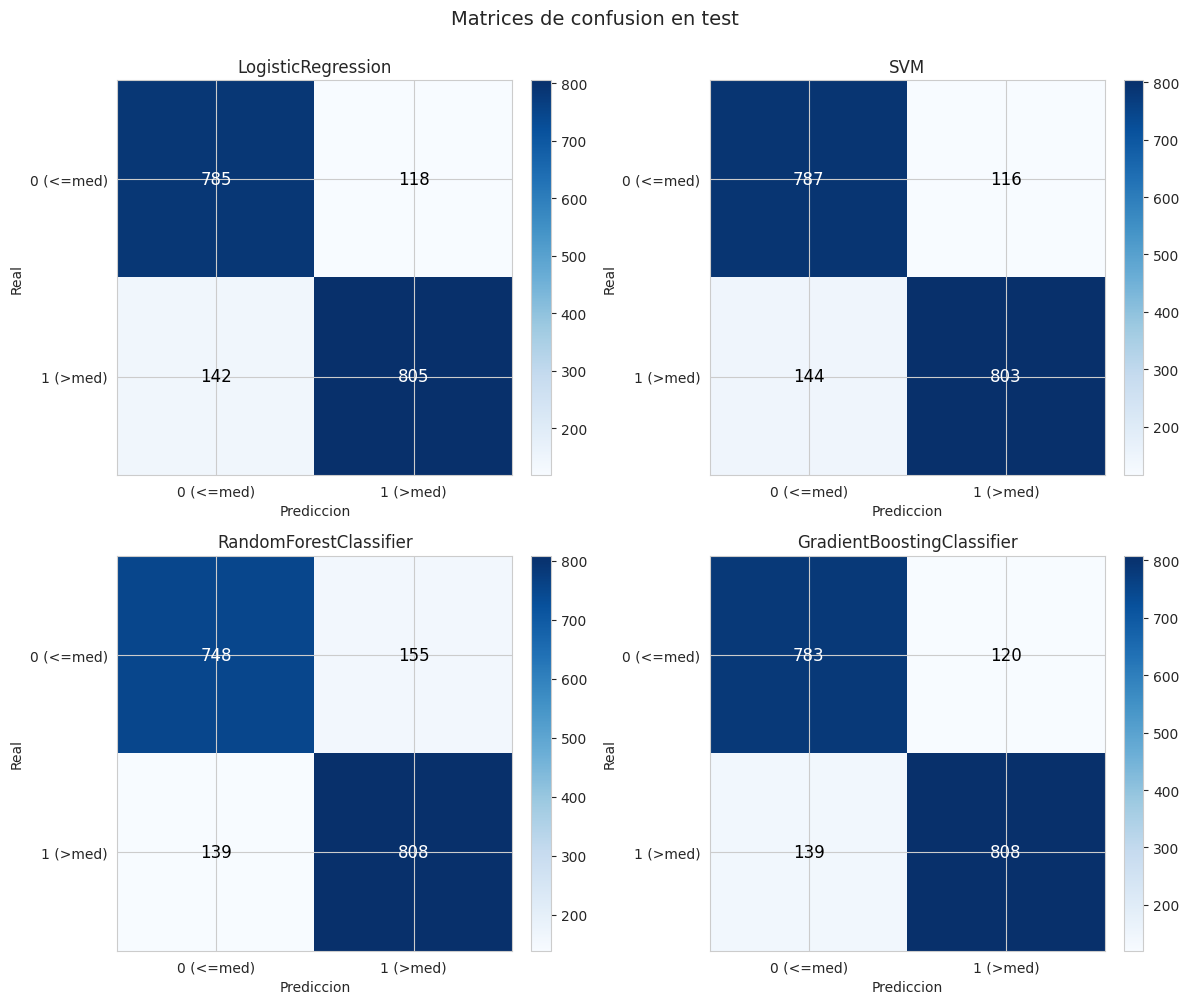

In [15]:
fig_cm = plot_confusion_matrices(clf_models, X_test, y_test_bin)
fig_cm.savefig(RESULTS_DIR / 'confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()


## 8. Curvas ROC superpuestas (clasificacion)

ROC traza TPR vs FPR a medida que movemos el umbral de decision. **Mayor area bajo la curva (AUC) = mejor capacidad discriminativa, independiente del umbral.** Una curva pegada al limite superior izquierdo es ideal; la diagonal punteada es el modelo aleatorio (AUC=0.5).


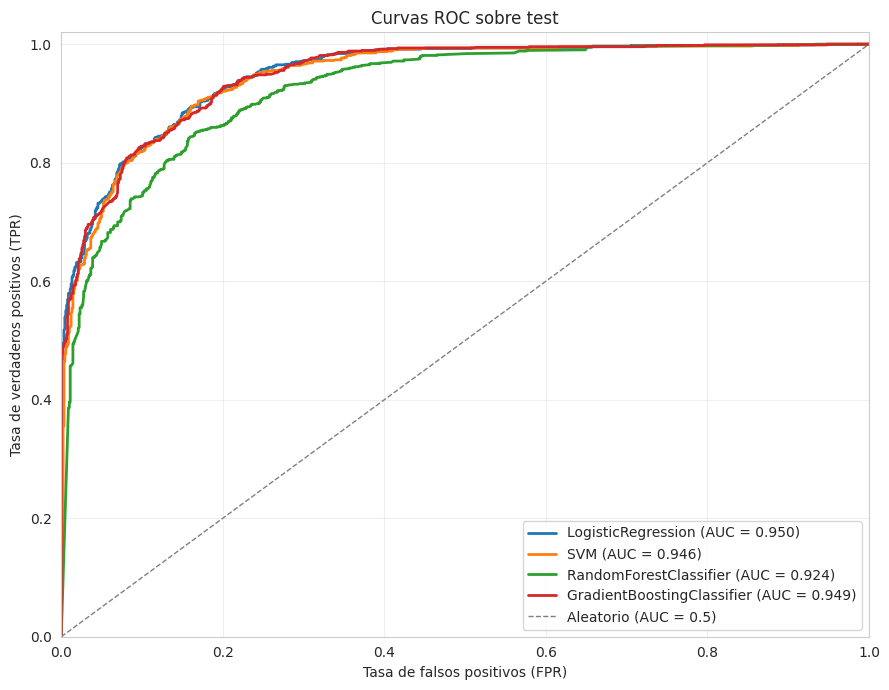

In [16]:
fig_roc = plot_roc_curves(clf_models, X_test, y_test_bin)
fig_roc.savefig(RESULTS_DIR / 'roc_curves.png', bbox_inches='tight', dpi=120)
plt.show()


## 9. classification_report del mejor modelo de clasificacion

El mejor modelo segun F1 medio en CV. `classification_report` muestra Precision/Recall/F1 por clase y los promedios macro/weighted -- util para detectar si una clase esta sistematicamente peor predicha.


In [17]:
best_clf_name = clf_table.index[0]
best_clf = clf_models[best_clf_name]
print(f'Mejor modelo de clasificacion segun CV: {best_clf_name}\n')
print(classification_report(
    y_test_bin, best_clf.predict(X_test),
    target_names=['<=mediana', '>mediana'], digits=3,
))


Mejor modelo de clasificacion segun CV: LogisticRegression

              precision    recall  f1-score   support

   <=mediana      0.847     0.869     0.858       903
    >mediana      0.872     0.850     0.861       947

    accuracy                          0.859      1850
   macro avg      0.859     0.860     0.859      1850
weighted avg      0.860     0.859     0.859      1850



## 10. Graficos de residuos (regresion)

Un residuo `e = y_real - y_pred` deberia distribuirse aleatoriamente alrededor de cero a lo largo de todo el rango de prediccion. Patrones a vigilar:

- **Curvatura sistematica:** el modelo no captura una relacion no lineal.
- **Embudo (heterocedasticidad):** la varianza del error cambia con el nivel del target -- frecuente en variables monetarias sin transformacion log.
- **Cluster de residuos extremos:** outliers que el modelo no maneja bien.


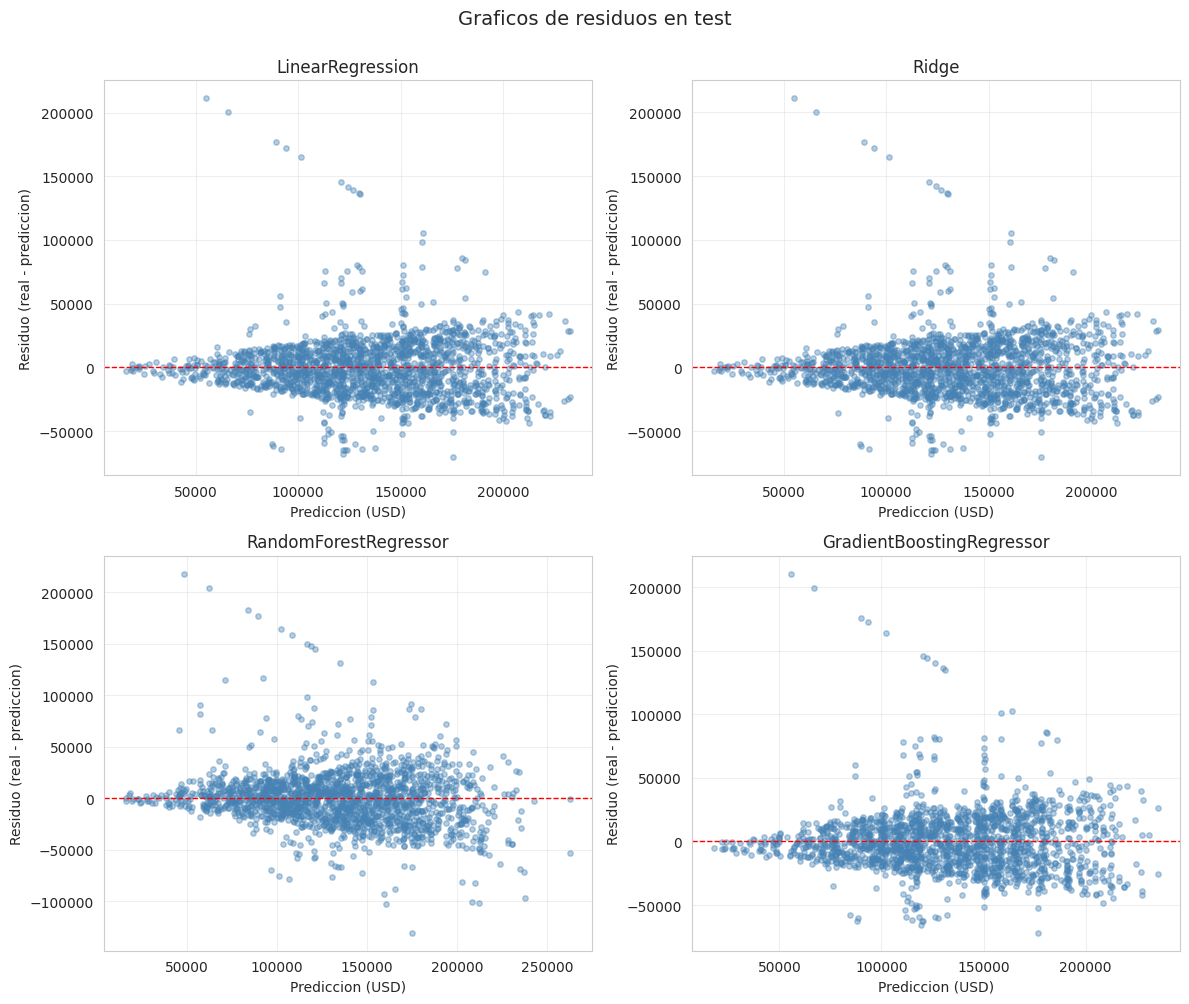

In [18]:
fig_res = plot_residuals(reg_models, X_test, y_test)
fig_res.savefig(RESULTS_DIR / 'residuals.png', bbox_inches='tight', dpi=120)
plt.show()


## 11. Diagnostico extendido del mejor modelo de regresion

Para el mejor regresor segun R^2 medio en CV:

- **Prediccion vs real con linea y = x:** si los puntos caen cerca de la diagonal en todo el rango, el modelo predice bien en todos los niveles de salario.
- **Histograma de residuos:** un histograma centrado en 0 y aproximadamente simetrico es lo ideal. Sesgo o colas pesadas indican problemas sistematicos.


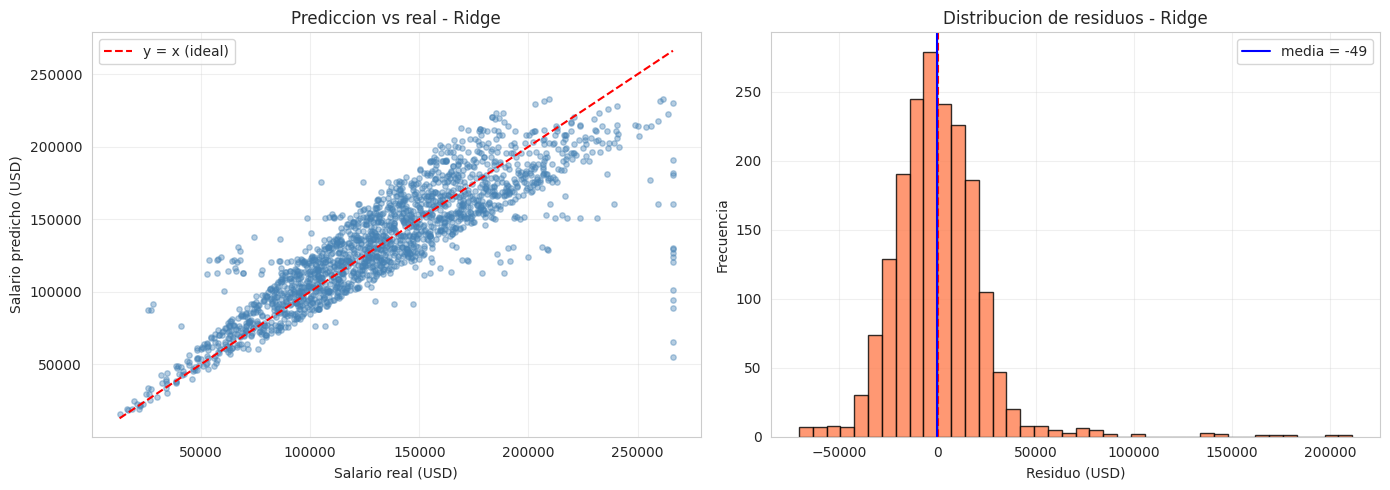

Mejor regresor segun CV: Ridge
Media de residuos: -48.66 USD
Std de residuos:   23,786.08 USD
Sesgo (skew):      2.066


In [19]:
best_reg_name = reg_table.index[0]
best_reg = reg_models[best_reg_name]
y_pred_best = best_reg.predict(X_test)
residuals_best = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.4, s=15, color='steelblue')
lo = min(y_test.min(), y_pred_best.min())
hi = max(y_test.max(), y_pred_best.max())
axes[0].plot([lo, hi], [lo, hi], color='red', linestyle='--', lw=1.5, label='y = x (ideal)')
axes[0].set_xlabel('Salario real (USD)')
axes[0].set_ylabel('Salario predicho (USD)')
axes[0].set_title(f'Prediccion vs real - {best_reg_name}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_best, bins=40, edgecolor='black', color='coral', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].axvline(residuals_best.mean(), color='blue', linestyle='-', lw=1.5,
                label=f'media = {residuals_best.mean():,.0f}')
axes[1].set_xlabel('Residuo (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribucion de residuos - {best_reg_name}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'best_regressor_diagnostics.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Mejor regresor segun CV: {best_reg_name}')
print(f'Media de residuos: {residuals_best.mean():,.2f} USD')
print(f'Std de residuos:   {residuals_best.std():,.2f} USD')
print(f'Sesgo (skew):      {pd.Series(residuals_best).skew():.3f}')


## 12. Conclusion y recomendacion para Fase 6


In [20]:
top2_reg = list(reg_table.index[:2])
top2_clf = list(clf_table.index[:2])

print('TOP 2 REGRESION (orden por R^2 medio en CV, descendente):')
for i, name in enumerate(top2_reg, 1):
    r2 = reg_table.loc[name, 'R2_mean_test']
    std = reg_table.loc[name, 'R2_std_test']
    gap = reg_table.loc[name, 'gap_R2']
    print(f'  {i}. {name}  R2={r2:.4f}+-{std:.4f}  gap_R2={gap:+.3f}')

print('\nTOP 2 CLASIFICACION (orden por F1 medio en CV, descendente):')
for i, name in enumerate(top2_clf, 1):
    f1 = clf_table.loc[name, 'F1_mean_test']
    std = clf_table.loc[name, 'F1_std_test']
    gap = clf_table.loc[name, 'gap_F1']
    print(f'  {i}. {name}  F1={f1:.4f}+-{std:.4f}  gap_F1={gap:+.3f}')


TOP 2 REGRESION (orden por R^2 medio en CV, descendente):
  1. Ridge  R2=0.7613+-0.0230  gap_R2=+0.002
  2. LinearRegression  R2=0.7613+-0.0230  gap_R2=+0.002

TOP 2 CLASIFICACION (orden por F1 medio en CV, descendente):
  1. LogisticRegression  F1=0.8771+-0.0071  gap_F1=+0.001
  2. GradientBoostingClassifier  F1=0.8769+-0.0103  gap_F1=+0.006


### Lectura para Fase 6 (tuning, notebook 04)

Los **2 mejores modelos por tarea segun CV** (mostrados arriba) son los que pasan a tuning. Justificacion:

- Se priorizo la metrica principal de cada tarea (R^2 para regresion, F1 para clasificacion) sobre la media en CV, no sobre el split unico de test del notebook 02. La CV es mas robusta porque promedia 5 evaluaciones.
- Cuando hay empate cercano en metrica, el desempate natural es **menor `gap_*`** (mejor generalizacion) y **menor `std_test`** (mayor estabilidad).
- En el notebook 04 se le aplicara **GridSearchCV** a uno y **RandomizedSearchCV** al otro -- la rubrica IEE 2.3.1 exige usar ambos metodos.

**Coincide con la anticipacion del notebook 02?** En el 02 dijimos que los candidatos naturales a tuning eran Random Forest y Gradient Boosting (los ensembles). La CV puede confirmar o desafiar eso: si los lineales/Dream Team quedan en el top 2, significa que la senal es esencialmente lineal y el techo del problema ya esta cerca. Igual entregamos al notebook 04 los 2 mejores de CV -- el tuning podra confirmar si tienen margen real para mejorar.

### Artefactos generados

- `results/cv_regression.csv` y `results/cv_classification.csv` -- tablas completas con medias, stds, gaps y tiempos.
- `results/confusion_matrices.png`, `results/roc_curves.png` -- diagnostico de clasificacion.
- `results/residuals.png`, `results/best_regressor_diagnostics.png` -- diagnostico de regresion.
